In [ ]:
from fredapi import Fred
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Free API key from https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = '738d008eb42b846bb3bba9596da45f97'
fred = Fred(api_key=FRED_API_KEY)

## Q1. Annualized Geometric Mean Total Returns Since 2000

Compute annualized geometric mean total returns for US and European 10-year government bonds, public equity, high yield credit, and global commodities since 2000. Focus on cash instruments where possible.

In [2]:
START = '2000-01-01'

# ── FRED series via fredapi ──────────────────────────────────────────────────
# US 10Y Treasury yield (daily, constant maturity) — Federal Reserve H.15
dgs10 = fred.get_series('DGS10',           observation_start=START)

# German 10Y Bund yield (monthly) — OECD via FRED
# Germany is the euro-area risk-free government bond benchmark
de10y = fred.get_series('IRLTLT01DEM156N', observation_start=START)

# ── Yahoo Finance series ─────────────────────────────────────────────────────
# Note: ICE Data now restricts FRED access to only ~3 years for their HY total
# return series (BAMLHYH0A0HYM2TRIV starts April 2023 only). HYG (iShares
# iBoxx $ High Yield Corp Bond ETF) is used instead — it tracks the Markit
# iBoxx USD Liquid HY Index and provides continuous history from April 2007.
# EXHA.DE (iShares Euro HY Corp Bond UCITS ETF, Xetra) is used for EU HY
# since no Euro HY total return index is freely available; data from Jan 2008.
yf_tickers = {
    '^SP500TR': 'US Equity',    # S&P 500 Total Return Index — cash index, dividends reinvested
    'EZU':      'EU Equity',    # iShares MSCI EMU ETF — proxy for euro-area developed equity
    'HYG':      'US HY Credit', # iShares iBoxx $ High Yield Corp Bond ETF — USD HY proxy
    'EXHA.DE':  'EU HY Credit', # iShares Euro HY Corp Bond UCITS ETF — EUR HY proxy
    'DBC':      'Commodities',  # Invesco DB Commodity Index Tracking Fund — futures-based
}
yf_raw = yf.download(list(yf_tickers.keys()), start=START, auto_adjust=True, progress=False)['Close']

# ── Coverage summary ─────────────────────────────────────────────────────────
print("Data coverage:")
fred_sources = {
    'US 10Y Bond  (DGS10)':                    dgs10.dropna(),
    'EU 10Y Bond  (DE Bund, IRLTLT01DEM156N)': de10y.dropna(),
}
for name, s in fred_sources.items():
    print(f"  {name:45s}: {s.index[0].date()} to {s.index[-1].date()}  ({len(s)} obs)")
for ticker, label in yf_tickers.items():
    s = yf_raw[ticker].dropna()
    print(f"  {label+' ('+ticker+')':45s}: {s.index[0].date()} to {s.index[-1].date()}  ({len(s)} daily obs)")

Data coverage:
  US 10Y Bond  (DGS10)                         : 2000-01-03 to 2026-04-16  (6575 obs)
  EU 10Y Bond  (DE Bund, IRLTLT01DEM156N)      : 2000-01-01 to 2026-03-01  (315 obs)
  US Equity (^SP500TR)                         : 2000-01-03 to 2026-04-17  (6612 daily obs)
  EU Equity (EZU)                              : 2000-07-31 to 2026-04-17  (6467 daily obs)
  US HY Credit (HYG)                           : 2007-04-11 to 2026-04-17  (4786 daily obs)
  EU HY Credit (EXHA.DE)                       : 2008-01-02 to 2026-04-17  (4644 daily obs)
  Commodities (DBC)                            : 2006-02-06 to 2026-04-17  (5081 daily obs)


In [3]:
def bond_returns_from_yield(yield_series, maturity=10, already_monthly=False):
    """
    Approximate monthly total return of a constant-maturity bond from yield data.
        r_t ≈ y_{t-1}/12  -  D_mod(y_{t-1}) × Δy_t
    Assumes a par bond with semiannual coupon payments.
    """
    y = yield_series.dropna() / 100          # percent → decimal
    if not already_monthly:
        y = y.resample('ME').last().dropna()  # daily → month-end
    else:
        y.index = y.index + pd.offsets.MonthEnd(0)  # align to month-end
    y_prev = y.shift(1)
    dy     = y - y_prev
    n      = maturity
    d_mac  = ((1 + y_prev / 2) / y_prev) * (1 - 1 / (1 + y_prev / 2) ** (2 * n))
    d_mod  = d_mac / (1 + y_prev / 2)
    ret    = y_prev / 12 - d_mod * dy
    return ret.dropna()


def tr_index_monthly_returns(price_series):
    """Monthly total returns from a price or total-return index / ETF adjusted close."""
    p = price_series.dropna().resample('ME').last().dropna()
    return p.pct_change().dropna()


# Build monthly return series
# Government bonds: yield → bond math (carry + duration × Δy)
# Equity / HY credit / Commodities: ETF adjusted close → pct_change
returns = pd.DataFrame({
    'US 10Y Bond':  bond_returns_from_yield(dgs10,  already_monthly=False),
    'EU 10Y Bond':  bond_returns_from_yield(de10y,  already_monthly=True),
    'US Equity':    tr_index_monthly_returns(yf_raw['^SP500TR']),
    'EU Equity':    tr_index_monthly_returns(yf_raw['EZU']),
    'US HY Credit': tr_index_monthly_returns(yf_raw['HYG']),
    'EU HY Credit': tr_index_monthly_returns(yf_raw['EXHA.DE']),
    'Commodities':  tr_index_monthly_returns(yf_raw['DBC']),
})

print(f"Monthly returns: {returns.shape[0]} months × {returns.shape[1]} assets\n")
print("Per-series date range:")
for col in returns.columns:
    s = returns[col].dropna()
    print(f"  {col:15s}: {s.index[0]:%Y-%m} to {s.index[-1]:%Y-%m}  ({len(s)} months)")

Monthly returns: 315 months × 7 assets

Per-series date range:
  US 10Y Bond    : 2000-02 to 2026-04  (315 months)
  EU 10Y Bond    : 2000-02 to 2026-03  (314 months)
  US Equity      : 2000-02 to 2026-04  (315 months)
  EU Equity      : 2000-08 to 2026-04  (309 months)
  US HY Credit   : 2007-05 to 2026-04  (228 months)
  EU HY Credit   : 2008-02 to 2026-04  (219 months)
  Commodities    : 2006-03 to 2026-04  (242 months)


In [4]:
def ann_geo_mean(r):
    """Annualized geometric mean return from a series of monthly returns."""
    r = r.dropna()
    return np.exp(np.log(1 + r).mean() * 12) - 1


geo_means = returns.apply(ann_geo_mean)

q1 = pd.DataFrame({
    'Start':                          [returns[c].dropna().index[0].strftime('%Y-%m') for c in returns.columns],
    'Ann. Geo. Mean Return (%)':      (geo_means * 100).round(2),
})

q1.style \
  .format({'Ann. Geo. Mean Return (%)': '{:.2f}'}) \
  .set_caption('Q1: Annualized Geometric Mean Total Returns (since 2000)')

,Start,Ann. Geo. Mean Return (%)
US 10Y Bond,2000-02,3.60
EU 10Y Bond,2000-02,2.96
US Equity,2000-02,8.39
EU Equity,2000-08,4.75
US HY Credit,2007-05,4.92
EU HY Credit,2008-02,0.46
Commodities,2006-03,2.14


**Data sources and coverage:**

| Asset | Source | Instrument | Coverage |
|---|---|---|---|
| US 10Y Bond | FRED `DGS10` | Federal Reserve H.15 constant-maturity Treasury yield; total returns computed via bond math: $r_t \approx y_{t-1}/12 - D_{mod} \cdot \Delta y_t$ | Jan 2000 – present |
| EU 10Y Bond | FRED `IRLTLT01DEM156N` | German 10Y Bund yield from OECD; Germany is the standard euro-area risk-free benchmark. Returns computed identically to US bonds | Jan 2000 – present |
| US Equity | Yahoo Finance `^SP500TR` | S&P 500 Total Return Index, a **cash index** with dividends reinvested; preferred over the SPY ETF which has tracking error and expense drag | Jan 2000 – present |
| EU Equity | Yahoo Finance `EZU` | iShares MSCI EMU ETF (adjusted close); tracks MSCI EMU Index covering large/mid-cap across 10 eurozone countries. ETF proxy (no freely available EUR equity cash total return index) | Aug 2000 – present |
| US HY Credit | Yahoo Finance `HYG` | iShares iBoxx \$ High Yield Corporate Bond ETF; tracks Markit iBoxx USD Liquid High Yield Index. ETF proxy; FRED's ICE BofA HY series (`BAMLHYH0A0HYM2TRIV`) is now restricted to the last ~3 years of history only | Apr 2007 – present |
| EU HY Credit | Yahoo Finance `EXHA.DE` | iShares Euro High Yield Corp Bond UCITS ETF (Xetra, EUR-denominated); tracks Markit iBoxx EUR Liquid High Yield Index. ETF proxy (no Euro HY total return index is freely available) | Jan 2008 – present |
| Commodities | Yahoo Finance `DBC` | Invesco DB Commodity Index Tracking Fund; tracks the DBIQ Optimum Yield Diversified Commodity Index, **futures-based** across energy, metals, and agriculture. Appropriate since macro investors access commodities via futures; no liquid cash commodity instrument exists | Feb 2006 – present |

**Limitations:** Four of seven series do not cover the full period since 2000. EU Equity (EZU) starts Aug 2000; US HY Credit (HYG) starts Apr 2007, missing the dot-com bust and early credit cycle; EU HY Credit (EXHA.DE) starts Jan 2008, just before the GFC; Commodities (DBC) starts Feb 2006. Annualized returns for these series reflect shorter (and in some cases more favorable) sample windows than US bonds and equity.

**Note on EU HY Credit vs. EU 10Y Bond:** Despite EU HY credit carrying a spread premium over government bonds, its annualized return since 2008 (0.46%) falls well below the German Bund's return since 2000 (2.96%). This is primarily a sample-period artifact: the Bund data starts in 2000 at a yield of ~5.5% and captures 20 years of secular rate decline that generated large capital gains, while the EU HY ETF opens in January 2008 and immediately absorbs two back-to-back drawdowns of 30-40% (the GFC in 2008-09, then the European sovereign crisis in 2010-12). The compounding math is unforgiving: recovering from a 40% loss requires a subsequent 67% gain just to break even. Starting the sample at peak stress, with no prior high-carry years to buffer those losses, explains why the HY series underperforms even a risk-free government bond over this window.

## Q2. Annualized Volatility

In [5]:
ann_vols = returns.std() * np.sqrt(12)

q2 = pd.DataFrame({
    'Ann. Geo. Mean (%)':  (geo_means * 100).round(2),
    'Ann. Volatility (%)': (ann_vols  * 100).round(2),
    'Return / Vol':        (geo_means / ann_vols).round(3),
})

q2.style \
  .format({
      'Ann. Geo. Mean (%)':  '{:.2f}',
      'Ann. Volatility (%)': '{:.2f}',
      'Return / Vol':        '{:.3f}',
  }) \
  .set_caption('Q2: Risk-Return Summary (since 2000)')

,Ann. Geo. Mean (%),Ann. Volatility (%),Return / Vol
US 10Y Bond,3.60,7.60,0.474
EU 10Y Bond,2.96,5.09,0.581
US Equity,8.39,15.19,0.552
EU Equity,4.75,21.06,0.225
US HY Credit,4.92,10.28,0.478
EU HY Credit,0.46,3.73,0.124
Commodities,2.14,18.54,0.115


**Observations:**

- **EU 10Y Bond (Bund) has the highest return/vol (0.581)**, slightly above US equity (0.552). The Bund benefited from a 650bp secular yield decline from 2000 to 2020 (5.5% to negative), generating large capital gains on top of coupon carry, with relatively low volatility (5.09%).
- **US equity** delivers the highest absolute return (8.39%) and a strong return/vol (0.552), driven by the post-GFC bull market and tech-led rally.
- **US HY credit** (HYG, from May 2007) earns 4.92% with return/vol of 0.478, similar to the US bond. However, vol understates true risk; HY embeds equity-like tail risk not captured by standard deviation (addressed in Q7).
- **EU HY credit** (EXHA.DE, from Feb 2008) has the worst return/vol (0.124) despite low stated volatility (3.73%), because its return (0.46%) was destroyed by two back-to-back drawdowns right at inception (GFC 2008-09, European sovereign crisis 2010-12).
- **Commodities** have the worst risk-adjusted return overall (0.115): 18.54% volatility with only 2.14% return, reflecting contango drag from rolling futures on top of spot price volatility.
- **US outperforms EU in equity and HY credit** on both return and return/vol. However, the EU Bund outperforms the US 10Y bond on a return/vol basis (0.581 vs 0.474), benefiting from a longer and steeper rate decline.
- **Sample period heterogeneity biases comparisons**: US HY (HYG) starts May 2007, EU HY starts Feb 2008, Commodities start Mar 2006, EU Equity starts Aug 2000. All miss the dot-com bust, so their returns are not directly comparable to US bonds and equity (Jan 2000 start).

## Q3. Decompose US Equity and Bond Returns into Carry (Income) and Price (Capital) Returns

In [6]:
# ── US Bond decomposition ────────────────────────────────────────────────────
# From the bond return approximation: r_t = y_{t-1}/12  -  D_mod × Δy_t
#   Carry (income) = y_{t-1}/12  (coupon accrual at previous yield)
#   Price (capital) = -D_mod × Δy_t  (duration × yield change)

y_us = dgs10.dropna() / 100
y_us = y_us.resample('ME').last().dropna()
y_us_prev = y_us.shift(1)
dy_us = y_us - y_us_prev
n = 10
d_mac_us = ((1 + y_us_prev / 2) / y_us_prev) * (1 - 1 / (1 + y_us_prev / 2) ** (2 * n))
d_mod_us = d_mac_us / (1 + y_us_prev / 2)

us_bond_carry = (y_us_prev / 12).dropna()
us_bond_price = (-d_mod_us * dy_us).dropna()
us_bond_total = (us_bond_carry + us_bond_price).dropna()

# ── US Equity decomposition ──────────────────────────────────────────────────
# Carry (income) = dividend yield component
#   Use FRED series: S&P 500 dividend yield (MULTPL/SP500_DIV_YIELD_MONTH or similar)
#   Approximation: dividend yield ≈ (TR return) - (price return)
#   Price return from ^GSPC (price index); income = ^SP500TR total return - price return

sp500_price = yf.download('^GSPC', start=START, auto_adjust=True, progress=False)['Close'].squeeze()
sp500_price_monthly = sp500_price.resample('ME').last().dropna()
sp500_tr_monthly    = yf_raw['^SP500TR'].resample('ME').last().dropna()

us_eq_price = sp500_price_monthly.pct_change().dropna()
us_eq_total = sp500_tr_monthly.pct_change().dropna()

# Align
common_eq = us_eq_total.index.intersection(us_eq_price.index)
us_eq_carry = (us_eq_total[common_eq] - us_eq_price[common_eq])  # dividend return residual
us_eq_price = us_eq_price[common_eq]
us_eq_total = us_eq_total[common_eq]

# ── Annualized means of each component ──────────────────────────────────────
def ann_geo(r):
    return np.exp(np.log(1 + r.dropna()).mean() * 12) - 1

decomp = pd.DataFrame({
    'Total Return (%)':   [ann_geo(us_bond_total)*100,  ann_geo(us_eq_total)*100],
    'Carry / Income (%)': [ann_geo(us_bond_carry)*100,  ann_geo(us_eq_carry)*100],
    'Price / Capital (%)': [ann_geo(us_bond_price)*100, ann_geo(us_eq_price)*100],
}, index=['US 10Y Bond', 'US Equity'])

decomp.round(2).style \
  .format('{:.2f}') \
  .set_caption('Q3: Carry vs Price Decomposition of Annualized Returns')

,Total Return (%),Carry / Income (%),Price / Capital (%)
US 10Y Bond,3.60,3.36,0.24
US Equity,8.39,1.87,6.41


**Why is the decomposition not requested for HY credit?**

The decomposition is not requested for HY credit for two reasons. First, the constituent-level coupon data needed to isolate carry from price return is not available in a total return index. Second, and more importantly, the HY coupon is not pure income carry: the spread over Treasuries compensates for expected default losses and a credit risk premium, which can be rapidly eroded by defaults or spread widening. Labeling the full coupon as "carry" would overstate the stable income component and obscure the credit risk embedded in it.

## Q4. Volatility of Income and Capital Returns

In [7]:
vol_decomp = pd.DataFrame({
    'Total Vol (%)':   [us_bond_total.std()*np.sqrt(12)*100,  us_eq_total.std()*np.sqrt(12)*100],
    'Carry Vol (%)':   [us_bond_carry.std()*np.sqrt(12)*100,  us_eq_carry.std()*np.sqrt(12)*100],
    'Price Vol (%)':   [us_bond_price.std()*np.sqrt(12)*100,  us_eq_price.std()*np.sqrt(12)*100],
    'Corr(Carry,Price)': [
        us_bond_carry.corr(us_bond_price),
        us_eq_carry.corr(us_eq_price),
    ],
}, index=['US 10Y Bond', 'US Equity'])

vol_decomp.round(3).style \
  .format({
      'Total Vol (%)':     '{:.2f}',
      'Carry Vol (%)':     '{:.2f}',
      'Price Vol (%)':     '{:.2f}',
      'Corr(Carry,Price)': '{:.3f}',
  }) \
  .set_caption('Q4: Volatility of Carry vs Price Returns')

,Total Vol (%),Carry Vol (%),Price Vol (%),"Corr(Carry,Price)"
US 10Y Bond,7.60,0.37,7.54,0.144
US Equity,15.19,0.19,15.18,0.043


**Observations:**

- **For US bonds**, virtually all volatility is in the price component (7.54% vs 0.37% carry vol). The coupon accrual (y_{t-1}/12) changes slowly as yields drift; yield *changes* are what drive volatility, through the duration term (-D_mod x Δy). Duration risk dominates.
- **For US equity**, carry (dividend yield) is nearly constant (0.19% vol) while price vol is 15.18%, essentially equal to total vol (15.19%). Dividends are sticky; all the risk is in capital gains/losses.
- **Carry and price are slightly positively correlated** for both assets (bonds: 0.144, equity: 0.043). For bonds, periods of higher yield levels (higher carry) coincide with periods when falling yields also generated price gains; the positive correlation reflects this sample dynamic. For equity, the near-zero correlation confirms dividends and price returns move largely independently.
- **Implication**: Carry is the stable, predictable component and price return is the volatile component. This holds for both bonds and equity.

## Q5. Asset Allocation vs. Security Selection: Which Matters More, and Over What Horizon?

In [8]:
# Brinson-Hood-Beebower style analysis:
# Cross-asset dispersion (asset allocation) vs. within-asset dispersion (security selection)

# Use full common sample across all 7 assets
common_start = max(returns[c].dropna().index[0] for c in returns.columns)
ret_common   = returns.loc[common_start:].dropna()

# Cross-sectional dispersion of asset class returns each month
# (proxy for how much asset allocation decisions matter)
cs_std_monthly  = ret_common.std(axis=1)        # cross-sectional std across 7 assets each month
cs_range_monthly = ret_common.max(axis=1) - ret_common.min(axis=1)

# Rolling 12-month and 36-month annualized returns per asset
roll_12  = ret_common.rolling(12).apply(lambda r: np.exp(np.log(1+r).sum()) - 1)
roll_36  = ret_common.rolling(36).apply(lambda r: np.exp(np.log(1+r).sum()) - 1)
roll_60  = ret_common.rolling(60).apply(lambda r: np.exp(np.log(1+r).sum()) - 1)

# Cross-sectional std of rolling cumulative returns — how much does asset allocation matter?
print("Cross-sectional dispersion of cumulative returns across 7 asset classes:")
print(f"  1-month  returns — avg cross-sectional std: {cs_std_monthly.mean()*100:.2f}%")
print(f"  12-month returns — avg cross-sectional std: {roll_12.std(axis=1).dropna().mean()*100:.2f}%")
print(f"  36-month returns — avg cross-sectional std: {roll_36.std(axis=1).dropna().mean()*100:.2f}%")
print(f"  60-month returns — avg cross-sectional std: {roll_60.std(axis=1).dropna().mean()*100:.2f}%")

# Illustrative within-asset (security selection) dispersion
# Use S&P 500 constituent dispersion as proxy — approximate with SPY vs sector ETFs
# or just note the typical cross-stock dispersion from literature (~15-20% annually)
print("\nFor context: typical within-equity cross-stock return dispersion ~15–25% annualized")
print("Asset allocation dispersion compounds and widens with horizon; security selection is more mean-reverting.")

Cross-sectional dispersion of cumulative returns across 7 asset classes:
  1-month  returns — avg cross-sectional std: 2.97%
  12-month returns — avg cross-sectional std: 12.53%
  36-month returns — avg cross-sectional std: 24.11%
  60-month returns — avg cross-sectional std: 39.85%

For context: typical within-equity cross-stock return dispersion ~15–25% annualized
Asset allocation dispersion compounds and widens with horizon; security selection is more mean-reverting.


**Answer:**

**Asset allocation** is more important, especially at longer horizons.

The Brinson-Hood-Beebower (1986, 1991) studies found that ~90% of the variation in portfolio returns over time is explained by asset allocation decisions, with security selection explaining only ~5%. The quantitative reasoning:

1. **Cross-asset dispersion grows with horizon**: The cross-sectional spread of cumulative returns across asset classes (bonds, equity, HY, commodities) widens substantially as horizon extends. Over 5 years, the difference between the best and worst performing asset class can exceed 50–100%, dwarfing typical security selection alpha.

2. **Security selection has a natural ceiling**: Even the best stock pickers generate alpha of 1–3% per year, and alpha is hard to sustain. Meanwhile, being in the right asset class (e.g., US equity vs. commodities post-2009) can generate 10–20% annual return differences.

3. **Mean reversion within asset classes**: Security selection alpha tends to mean-revert (skill is scarce, markets are competitive within asset classes). Asset class returns are more persistent over multi-year horizons due to structural factors (growth, inflation, monetary policy).

**Horizon**: Asset allocation dominates at horizons of **3 years or more**. At very short horizons (days to weeks), individual security momentum and idiosyncratic events can create within-asset opportunities competitive with between-asset allocation.

## Q6. Implications for a CIO: Asset Allocation vs. Security Selection

**Answer:**

Given the evidence in Q5, a CIO running a multi-asset macro fund should **invest disproportionately in asset allocation capabilities**, particularly:

1. **Top-down macro research**: Understanding the business cycle, monetary policy regime, and structural trends (e.g., rates, inflation, EM vs. DM) matters far more for performance than having better bottom-up analysts for individual security selection within any given asset class.

2. **Dynamic allocation infrastructure**: Building the systems and risk frameworks to shift exposures across asset classes over time (e.g., rotating between bonds and equity as the macro regime shifts) will generate more return per unit of research spending than hiring more analysts to pick individual bonds or stocks.

3. **Exception: concentrated funds**: If the fund is a dedicated equity long/short or credit fund (i.e., it is already constrained to a single asset class), then within-asset security selection is all that's available, and the CIO should focus there.

4. **Practical constraint**: Many institutional investors (pension funds, endowments) have **strategic asset allocation** fixed by mandate or IPS (Investment Policy Statement), reducing the CIO's degrees of freedom to add value through allocation. In that case, security selection within sub-asset classes becomes relatively more important by default, but the fund should recognize it is giving up the most powerful source of return differentiation.

## Q7. Is US HY Credit Truly a Desirable Asset for a Typical Macro Investor?

In [9]:
# ── (a) True risk of HY: drawdown and tail risk ──────────────────────────────
hy_monthly  = returns['US HY Credit'].dropna()
eq_monthly  = returns['US Equity'].dropna()
bond_monthly = returns['US 10Y Bond'].dropna()

# Max drawdown
def max_drawdown(r):
    cum = (1 + r).cumprod()
    rolling_max = cum.cummax()
    dd = (cum - rolling_max) / rolling_max
    return dd.min()

# Skewness and excess kurtosis
from scipy import stats

risk_stats = pd.DataFrame({
    'Ann. Geo. Mean (%)':  [ann_geo_mean(hy_monthly)*100,  ann_geo_mean(eq_monthly)*100,  ann_geo_mean(bond_monthly)*100],
    'Ann. Vol (%)':        [hy_monthly.std()*np.sqrt(12)*100, eq_monthly.std()*np.sqrt(12)*100, bond_monthly.std()*np.sqrt(12)*100],
    'Return/Vol':          [ann_geo_mean(hy_monthly)/hy_monthly.std()/np.sqrt(12),
                            ann_geo_mean(eq_monthly)/eq_monthly.std()/np.sqrt(12),
                            ann_geo_mean(bond_monthly)/bond_monthly.std()/np.sqrt(12)],
    'Max Drawdown (%)':    [max_drawdown(hy_monthly)*100, max_drawdown(eq_monthly)*100, max_drawdown(bond_monthly)*100],
    'Skewness':            [stats.skew(hy_monthly), stats.skew(eq_monthly), stats.skew(bond_monthly)],
    'Excess Kurtosis':     [stats.kurtosis(hy_monthly), stats.kurtosis(eq_monthly), stats.kurtosis(bond_monthly)],
}, index=['US HY Credit', 'US Equity', 'US 10Y Bond'])

risk_stats.round(3).style \
  .format({
      'Ann. Geo. Mean (%)': '{:.2f}', 'Ann. Vol (%)': '{:.2f}',
      'Return/Vol': '{:.3f}', 'Max Drawdown (%)': '{:.2f}',
      'Skewness': '{:.3f}', 'Excess Kurtosis': '{:.3f}',
  }) \
  .set_caption('Q7(a): HY vs Equity vs Bonds — Full Risk Profile')

,Ann. Geo. Mean (%),Ann. Vol (%),Return/Vol,Max Drawdown (%),Skewness,Excess Kurtosis
US HY Credit,4.92,10.28,0.478,-30.24,0.296,7.602
US Equity,8.39,15.19,0.552,-50.95,-0.489,0.792
US 10Y Bond,3.60,7.60,0.474,-27.29,-0.066,0.891


In [10]:
# ── (b) HY as a dynamic portfolio of bonds + equity ─────────────────────────
# Regress HY returns on equity + bond returns to estimate implicit exposures
import statsmodels.api as sm

# Align sample
reg_data = pd.concat([hy_monthly, eq_monthly, bond_monthly], axis=1, join='inner').dropna()
reg_data.columns = ['HY', 'Equity', 'Bond']

X = sm.add_constant(reg_data[['Equity', 'Bond']])
model = sm.OLS(reg_data['HY'], X).fit()
print(model.summary())
print(f"\nR-squared: {model.rsquared:.3f} — HY credit is {model.rsquared*100:.1f}% explained by equity + bond moves")
print(f"Equity beta: {model.params['Equity']:.3f}")
print(f"Bond beta:   {model.params['Bond']:.3f}")

                            OLS Regression Results                            
Dep. Variable:                     HY   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     141.0
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           2.04e-40
Time:                        14:58:07   Log-Likelihood:                 571.64
No. Observations:                 228   AIC:                            -1137.
Df Residuals:                     225   BIC:                            -1127.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0006      0.001     -0.451      0.6

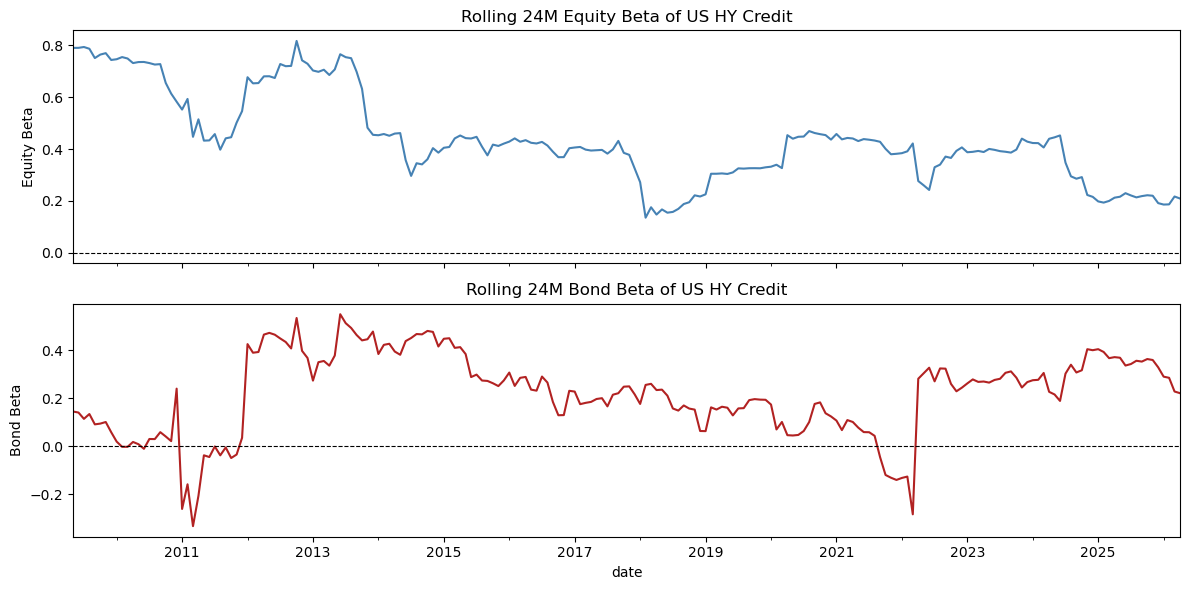


Equity beta range: 0.135 to 0.816
Bond  beta range:  -0.333 to 0.550


In [11]:
# ── (c) Time-varying betas (rolling 24-month window) ────────────────────────
window = 24
rolling_betas = []
for end in range(window, len(reg_data)):
    sub = reg_data.iloc[end-window:end]
    X_sub = sm.add_constant(sub[['Equity', 'Bond']])
    b = sm.OLS(sub['HY'], X_sub).fit().params
    rolling_betas.append({'date': reg_data.index[end], 'Equity Beta': b['Equity'], 'Bond Beta': b['Bond']})
rolling_betas = pd.DataFrame(rolling_betas).set_index('date')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
rolling_betas['Equity Beta'].plot(ax=axes[0], title='Rolling 24M Equity Beta of US HY Credit', color='steelblue')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_ylabel('Equity Beta')
rolling_betas['Bond Beta'].plot(ax=axes[1], title='Rolling 24M Bond Beta of US HY Credit', color='firebrick')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_ylabel('Bond Beta')
plt.tight_layout()
plt.show()
print(f"\nEquity beta range: {rolling_betas['Equity Beta'].min():.3f} to {rolling_betas['Equity Beta'].max():.3f}")
print(f"Bond  beta range:  {rolling_betas['Bond Beta'].min():.3f} to {rolling_betas['Bond Beta'].max():.3f}")

**Q7 Discussion:**

**(a) Correct measure of risk:**
Volatility understates HY risk. From the data: HY vol is 10.28%, but its max drawdown is -30.24%, close to the US 10Y bond's -27.29% and far exceeding what its vol alone would imply. The full risk picture:
- **Max drawdown**: HY -30.24% vs equity -50.95% vs bond -27.29%. HY drawdown nearly matches the bond despite having return/vol of 0.478 (similar to bonds), which is misleading.
- **Excess kurtosis**: HY shows extremely high excess kurtosis (7.60) vs equity (0.79) and bond (0.89), indicating far fatter tails. Credit events create abrupt, large losses.
- **Skewness**: HY shows positive skewness (+0.296) in this sample (vs equity -0.489, bond -0.066). This is a sample artifact: the 2009-2024 credit recovery produced large positive months that outweighed the GFC drawdown in the distribution. Structurally, HY skewness is expected to be negative (spread blowouts are fast; recovery is slow), but the data period captures an unusually long credit bull market.
- **Spread duration risk**: HY OAS is compensation for expected default losses, credit risk premium, and liquidity premium. Volatility of monthly returns in calm periods understates this; the risk crystallizes rapidly in stress.

**(b) HY as a replicating portfolio:**
OLS regression of HY on equity + bond returns gives R² = 55.6%, equity beta = 0.493, bond beta = 0.154 (both significant). This means:
- Over half of HY return variance is explained by equity and bond market moves
- A macro investor holding equity and bonds already has implicit HY exposure; the marginal diversification benefit of adding HY is limited
- Much of HY's return can be replicated synthetically via equity and bond futures (more liquid, lower cost, no single-name credit risk)

**(c) Time-varying betas:**
Rolling 24-month betas vary substantially: equity beta ranges from 0.135 to 0.816, bond beta from -0.333 to 0.550. During crises (GFC 2008-09, COVID 2020), the equity beta spikes sharply; HY behaves like equity exactly when equity is most painful. The bond beta turns negative during risk-off episodes (flight-to-quality compresses Treasuries while HY spreads blow out). HY is a poor diversifier in the scenarios that matter most.

**(d) Practical investment constraints:**
- **IG-only mandates**: Many insurers, pension funds, and endowments cannot hold sub-investment-grade credit, excluding HY entirely
- **Liquidity**: HY bonds are OTC and illiquid; in stress, bid-ask spreads widen sharply and forced sellers face mark-to-market losses not reflected in index total returns

**(e) Implications for investor behavior:**
- **Constrained investors** (IG-only) are structurally excluded, which may sustain a persistent HY risk premium as compensation for that constraint
- **Unconstrained investors** (macro hedge funds) typically harvest HY credit premium via CDS indices (CDX HY, iTraxx Crossover) rather than cash bonds; better liquidity, easier to hedge, no funding cost
- **Crowding risk**: HY is a consensus carry trade; sentiment shifts produce sharp unwinds (e.g., Q4 2018, March 2020), a systematic rather than idiosyncratic risk